# Adım 7 - Dashboard ve Görselleştirme

Bu notebook Adım 6'da üretilen model sonuçlarını ve Delta Lake tablosunu kullanarak 11 zorunlu görseli üretir.
Tüm görseller `dashboard` klasörüne `dpi=150` ile PNG olarak kaydedilir.


In [1]:
# Temel kütüphaneler ve proje klasörleri
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def find_base_dir() -> Path:
    # Notebook nereden çalışırsa çalışsın proje kökünü buluyoruz.
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() or (candidate / "docker-compose.yml").exists():
            return candidate
    if current.name.lower() == "notebooks":
        return current.parent
    return current

BASE_DIR = find_base_dir()
PROJECT_ROOT = BASE_DIR
DASHBOARD_DIR = BASE_DIR / "dashboard"
DASHBOARD_DATA_DIR = DASHBOARD_DIR / "data"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

# Dashboard için önce feature tablosu, sonra streaming katmanları denenir.
# Zaman serisi grafiği için seçilen tabloda Kafka timestamp kolonu bulunmalı.
DELTA_CANDIDATES = [
    PROJECT_ROOT / "delta-lake" / "gold" / "features",
    BASE_DIR / "delta-lake" / "gold" / "features",
    PROJECT_ROOT / "delta-lake" / "silver",
    BASE_DIR / "delta-lake" / "silver",
    PROJECT_ROOT / "delta-lake" / "bronze",
    BASE_DIR / "delta-lake" / "bronze",
    BASE_DIR / "data" / "delta" / "spotify_tracks",
    BASE_DIR / "delta" / "spotify_tracks",
    BASE_DIR / "spark" / "data" / "delta" / "spotify_tracks",
    PROJECT_ROOT / "data" / "delta" / "spotify_tracks",
    PROJECT_ROOT / "spark" / "data" / "delta" / "spotify_tracks",
    PROJECT_ROOT / "delta" / "spotify_tracks",
]

DELTA_TABLE_PATH = next(
    (path for path in DELTA_CANDIDATES if (path / "_delta_log").exists()),
    DELTA_CANDIDATES[0],
)

print(f"Proje kökü: {BASE_DIR}")
print(f"Dashboard klasörü: {DASHBOARD_DIR}")
print(f"Delta tablo yolu: {DELTA_TABLE_PATH}")


Proje kökü: /home/jovyan
Dashboard klasörü: /home/jovyan/dashboard
Delta tablo yolu: /home/jovyan/delta-lake/gold/features


In [2]:
# Adım 6'nın ürettiği sonuç dosyalarını oku
required_files = {
    "metrics": DASHBOARD_DATA_DIR / "model_metrics.csv",
    "rf_importance": DASHBOARD_DATA_DIR / "rf_feature_importance.csv",
    "roc": DASHBOARD_DATA_DIR / "roc_curve_points.csv",
    "confusion_matrix": DASHBOARD_DATA_DIR / "best_confusion_matrix.csv",
    "predictions": DASHBOARD_DATA_DIR / "best_model_predictions.csv",
    "metadata": DASHBOARD_DATA_DIR / "best_model_metadata.json",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Önce adim6_ml_mlflow.ipynb notebookunu baştan sona çalıştırmalısın. Eksik dosyalar: "
        + ", ".join(missing)
    )

metrics_df = pd.read_csv(required_files["metrics"])
rf_importance_df = pd.read_csv(required_files["rf_importance"])
roc_df = pd.read_csv(required_files["roc"])
confusion_df = pd.read_csv(required_files["confusion_matrix"], index_col=0)
predictions_df = pd.read_csv(required_files["predictions"])
with open(required_files["metadata"], "r", encoding="utf-8") as file:
    best_metadata = json.load(file)

best_model_name = best_metadata["best_model_name"]

display(metrics_df)
print("En iyi model:", best_model_name)


,model,experiment,run_id,accuracy,f1_weighted,precision_weighted,recall_weighted,auc_roc
0,Random Forest Classifier,Kisi4_Random_Forest_Classifier,3d6664908f2444528eb6da41f37d2eb1,0.559869,0.546891,0.564537,0.559869,0.944227
1,Gradient Boosted Trees (GBT) Classifier,Kisi4_GBT_Classifier,bdba765671eb48eb905df8981916c819,0.505926,0.502628,0.512976,0.505926,0.928316
2,Decision Tree Classifier,Kisi4_Decision_Tree_Classifier,0e331095d61d4970a5ca0738b516676b,0.480588,0.480489,0.518155,0.480588,0.899491
3,Logistic Regression,Kisi4_Logistic_Regression,0e0b046798774260a018c23786f200e3,0.466285,0.449011,0.466838,0.466285,0.919739
4,Naive Bayes,Kisi4_Naive_Bayes,3fbcda85d2b24d119e7cd388ea9c8fc9,0.299142,0.255803,0.309084,0.299142,0.855244


En iyi model: Random Forest Classifier


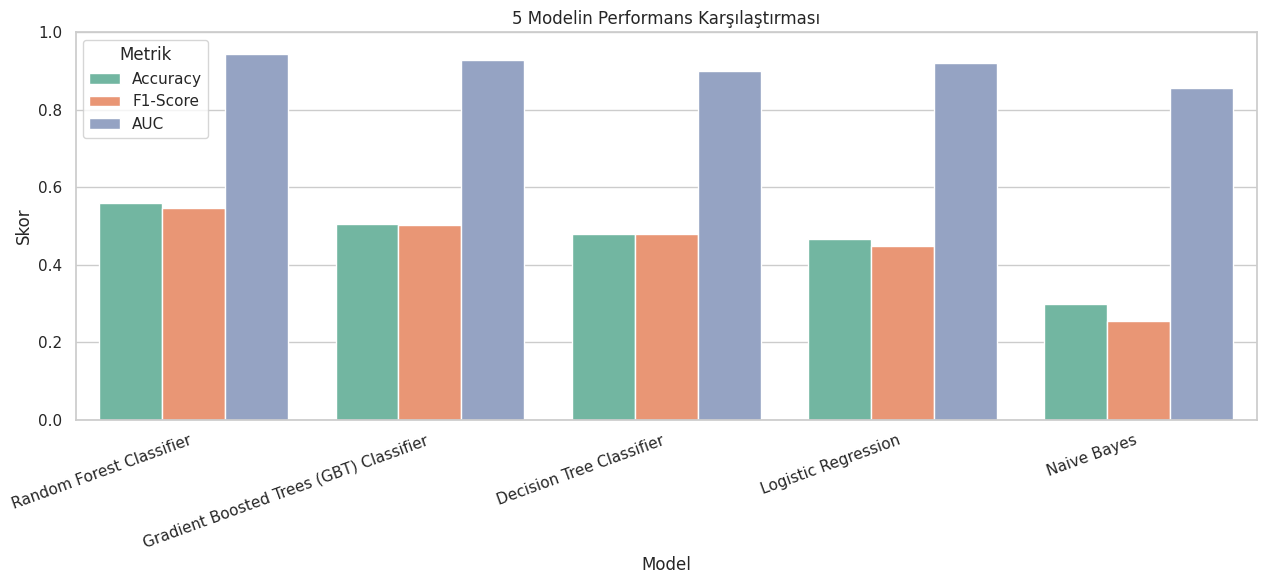

Bu grafik 5 modelin Accuracy, F1-Score ve AUC metriklerini karşılaştırır. Skoru daha yüksek olan model, ilgili metrikte daha başarılıdır.


In [3]:
# Görsel 1: 5 modelin performans karşılaştırması
metric_columns = ["accuracy", "f1_weighted", "auc_roc"]
metric_labels = {
    "accuracy": "Accuracy",
    "f1_weighted": "F1-Score",
    "auc_roc": "AUC",
}

plot_df = metrics_df[["model", *metric_columns]].melt(
    id_vars="model",
    value_vars=metric_columns,
    var_name="Metrik",
    value_name="Skor",
)
plot_df["Metrik"] = plot_df["Metrik"].map(metric_labels)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="model", y="Skor", hue="Metrik", palette="Set2")
plt.title("5 Modelin Performans Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metrik")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel1_model_karsilastirma.png", dpi=150)
plt.show()
print("Bu grafik 5 modelin Accuracy, F1-Score ve AUC metriklerini karşılaştırır. Skoru daha yüksek olan model, ilgili metrikte daha başarılıdır.")


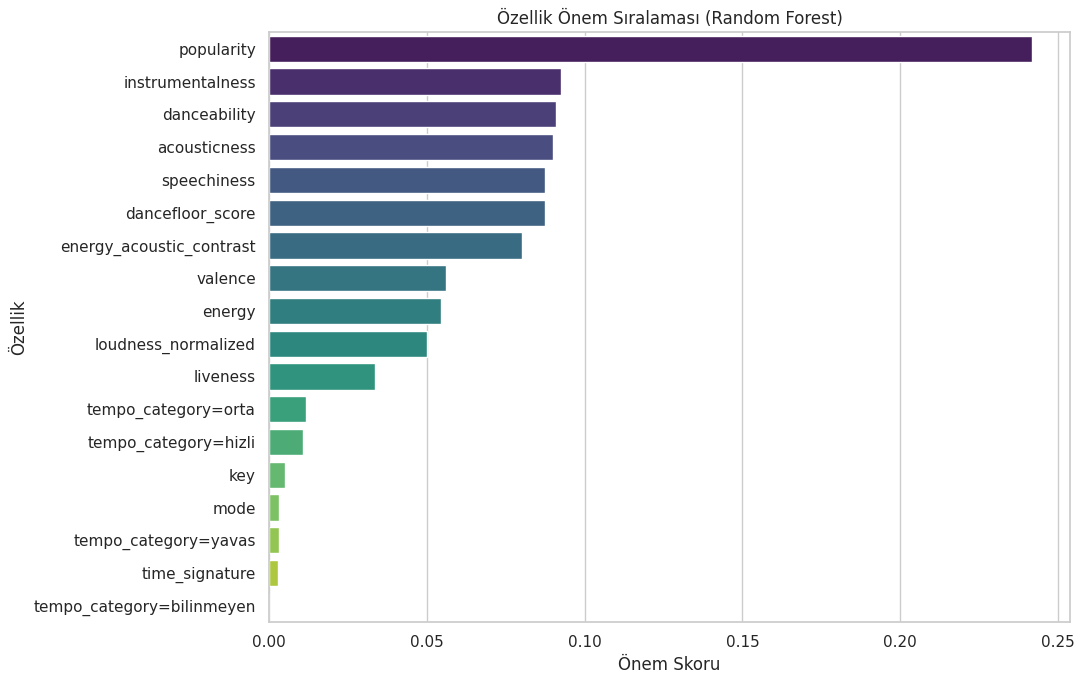

Bu grafik Random Forest modelinde tahmine en fazla katkı veren özellikleri önem skorlarına göre sıralar. Üst sıralardaki özellikler model kararlarında daha etkili olmuştur.


In [4]:
# Görsel 2: Random Forest feature importance yatay çubuk grafik
top_rf = rf_importance_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(data=top_rf, y="feature", x="importance", palette="viridis")
plt.title("Özellik Önem Sıralaması (Random Forest)")
plt.xlabel("Önem Skoru")
plt.ylabel("Özellik")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel2_feature_importance.png", dpi=150)
plt.show()
print("Bu grafik Random Forest modelinde tahmine en fazla katkı veren özellikleri önem skorlarına göre sıralar. Üst sıralardaki özellikler model kararlarında daha etkili olmuştur.")


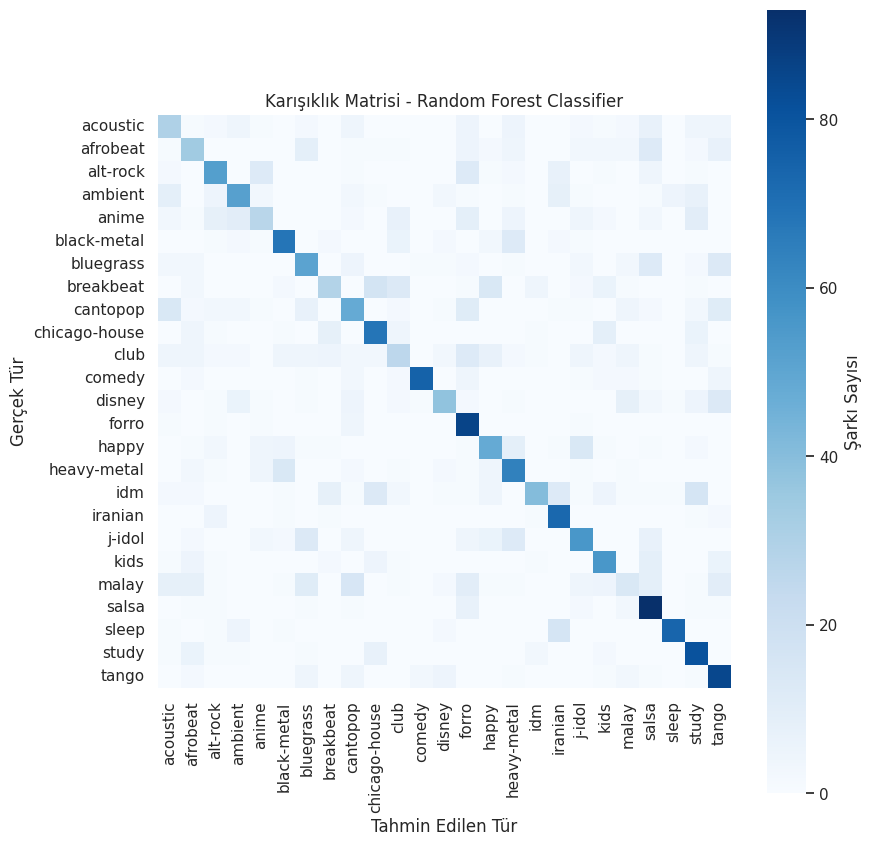

Bu heatmap en iyi modelin gerçek türler ile tahmin ettiği türleri ne kadar eşleştirdiğini gösterir. Diyagonal değerlerin yüksek olması modelin doğru sınıflandırma yaptığını gösterir.


In [5]:
# Görsel 3: En iyi modelin confusion matrix görseli
class_count = confusion_df.shape[0]
figure_size = max(9, min(24, class_count * 0.28))
show_tick_labels = class_count <= 35

plt.figure(figsize=(figure_size, figure_size))
sns.heatmap(
    confusion_df,
    cmap="Blues",
    square=True,
    xticklabels=show_tick_labels,
    yticklabels=show_tick_labels,
    cbar_kws={"label": "Şarkı Sayısı"},
)
plt.title(f"Karışıklık Matrisi - {best_model_name}")
plt.xlabel("Tahmin Edilen Tür")
plt.ylabel("Gerçek Tür")
if show_tick_labels:
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel3_confusion_matrix.png", dpi=150)
plt.show()
print("Bu heatmap en iyi modelin gerçek türler ile tahmin ettiği türleri ne kadar eşleştirdiğini gösterir. Diyagonal değerlerin yüksek olması modelin doğru sınıflandırma yaptığını gösterir.")


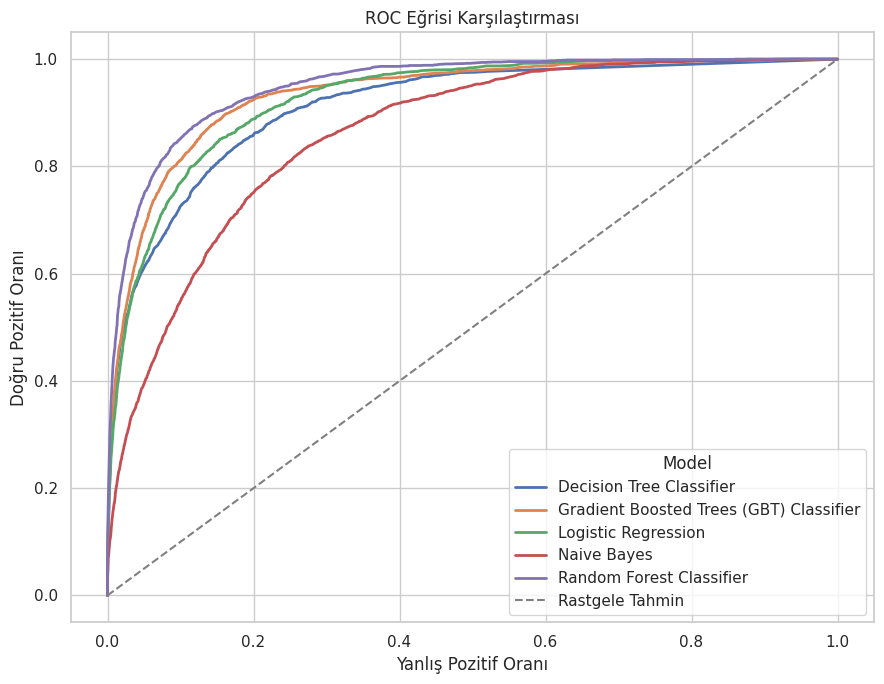

Bu ROC eğrisi modellerin sınıfları ayırt etme performansını karşılaştırır. Eğri sol üst köşeye yaklaştıkça modelin ayırt etme gücü artar.


In [6]:
# Görsel 4: ROC eğrisi karşılaştırması
plt.figure(figsize=(9, 7))
for model_name, group in roc_df.groupby("model"):
    plt.plot(group["fpr"], group["tpr"], linewidth=2, label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Rastgele Tahmin")
plt.title("ROC Eğrisi Karşılaştırması")
plt.xlabel("Yanlış Pozitif Oranı")
plt.ylabel("Doğru Pozitif Oranı")
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel4_roc_curve.png", dpi=150)
plt.show()
print("Bu ROC eğrisi modellerin sınıfları ayırt etme performansını karşılaştırır. Eğri sol üst köşeye yaklaştıkça modelin ayırt etme gücü artar.")


In [7]:
# Spark ve Delta Lake oturumu: zaman serisi, popularity ve tür dağılımı için Delta verisini okuyacağız.
from pyspark.sql import SparkSession, functions as F

try:
    from delta import configure_spark_with_delta_pip
except ModuleNotFoundError:
    configure_spark_with_delta_pip = None

spark_builder = (
    SparkSession.builder
    .appName("SpotifyDashboardVisuals")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.warehouse.dir", str(BASE_DIR / "spark-warehouse"))
)

if configure_spark_with_delta_pip is not None:
    spark = configure_spark_with_delta_pip(spark_builder).getOrCreate()
else:
    spark = spark_builder.getOrCreate()
spark.sparkContext.setLogLevel("WARN")

if not (DELTA_TABLE_PATH / "_delta_log").exists():
    raise FileNotFoundError("Delta tablosu bulunamadı. DELTA_TABLE_PATH değişkenini düzenle.")

delta_df = spark.read.format("delta").load(str(DELTA_TABLE_PATH))
print("Delta satır sayısı:", delta_df.count())


Delta satır sayısı: 89740


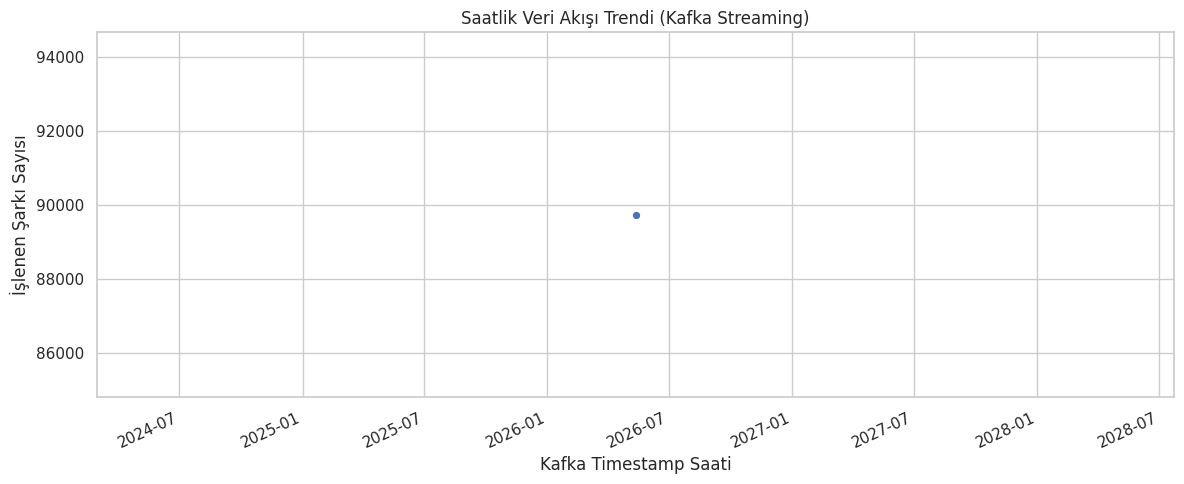

Bu çizgi grafik Kafka timestamp bilgisine göre saatlik işlenen şarkı sayısını gösterir. Zaman içinde veri akışında yoğunlaşma veya düşüş olup olmadığını izlemeye yarar.


In [8]:
# Görsel 5: Kafka timestamp kolonuyla saatlik veri akışı trendi
timestamp_candidates = ["kafka_timestamp", "timestamp"]
timestamp_col = next((col for col in timestamp_candidates if col in delta_df.columns), None)
if timestamp_col is None:
    raise ValueError("Delta tablosunda kafka_timestamp veya timestamp kolonu yok. Kafka Producer bu kolonlardan birini eklemeli.")

hourly_df = (
    delta_df
    .withColumn("kafka_timestamp", F.col(timestamp_col).cast("timestamp"))
    .where(F.col("kafka_timestamp").isNotNull())
    .withColumn("saat", F.date_trunc("hour", F.col("kafka_timestamp")))
    .groupBy("saat")
    .count()
    .orderBy("saat")
)

hourly_pdf = hourly_df.toPandas()
if hourly_pdf.empty:
    raise ValueError("timestamp kolonu timestamp tipine çevrilemedi veya boş geldi.")

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pdf, x="saat", y="count", marker="o", linewidth=2)
plt.title("Saatlik Veri Akışı Trendi (Kafka Streaming)")
plt.xlabel("Kafka Timestamp Saati")
plt.ylabel("İşlenen Şarkı Sayısı")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel5_zaman_serisi.png", dpi=150)
plt.show()
print("Bu çizgi grafik Kafka timestamp bilgisine göre saatlik işlenen şarkı sayısını gösterir. Zaman içinde veri akışında yoğunlaşma veya düşüş olup olmadığını izlemeye yarar.")


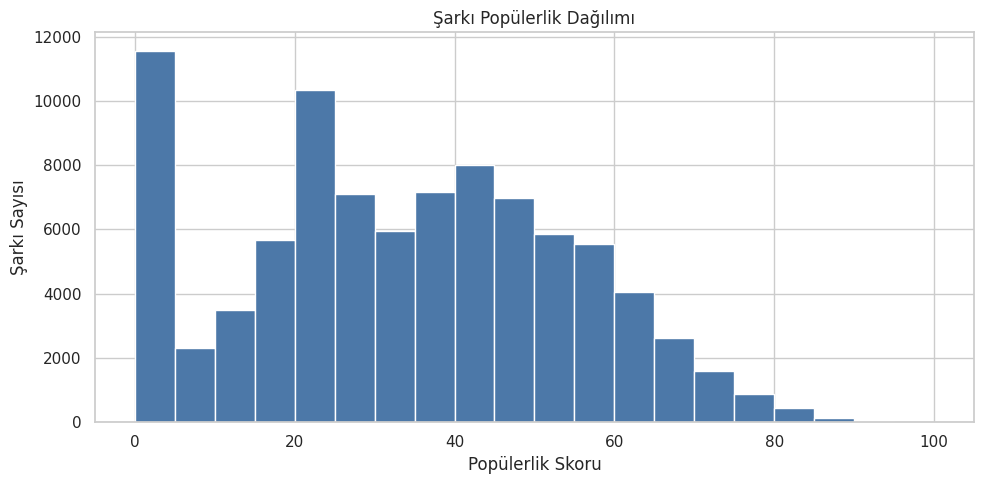

Bu histogram şarkıların popularity skorlarının hangi aralıklarda yoğunlaştığını gösterir. Dağılım, veri setinde popüler ve az popüler şarkı dengesini anlamayı sağlar.


In [9]:
# Görsel 6: Popularity dağılımı histogramı
if "popularity" not in delta_df.columns:
    raise ValueError("Delta tablosunda popularity kolonu yok.")

popularity_pdf = (
    delta_df
    .select(F.col("popularity").cast("double").alias("popularity"))
    .where(F.col("popularity").isNotNull())
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(popularity_pdf["popularity"], bins=20, range=(0, 100), color="#4C78A8", edgecolor="white")
plt.title("Şarkı Popülerlik Dağılımı")
plt.xlabel("Popülerlik Skoru")
plt.ylabel("Şarkı Sayısı")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel6_popularity_histogram.png", dpi=150)
plt.show()
print("Bu histogram şarkıların popularity skorlarının hangi aralıklarda yoğunlaştığını gösterir. Dağılım, veri setinde popüler ve az popüler şarkı dengesini anlamayı sağlar.")


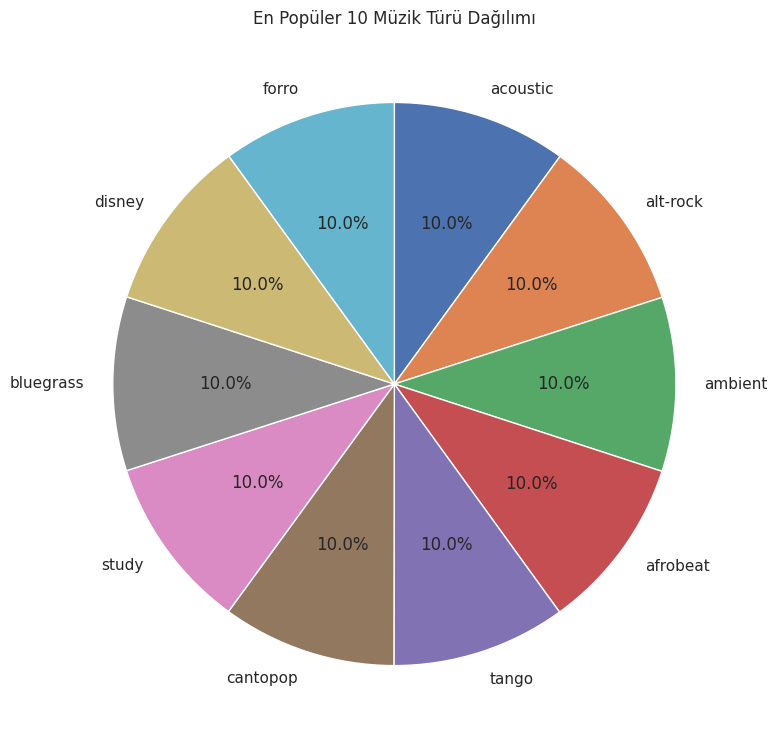

Bu pasta grafik veri setinde en sık görülen 10 müzik türünün oranını gösterir. Büyük dilimler, veri setinde daha fazla temsil edilen türleri ifade eder.


In [10]:
# Görsel 7: En popüler 10 tür dağılımı pie chart
if "track_genre" not in delta_df.columns:
    raise ValueError("Delta tablosunda track_genre kolonu yok.")

top_genres_pdf = (
    delta_df
    .groupBy("track_genre")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(8, 8))
plt.pie(
    top_genres_pdf["count"],
    labels=top_genres_pdf["track_genre"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
plt.title("En Popüler 10 Müzik Türü Dağılımı")
plt.ylabel("")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel7_tur_dagilimi_pie.png", dpi=150)
plt.show()
print("Bu pasta grafik veri setinde en sık görülen 10 müzik türünün oranını gösterir. Büyük dilimler, veri setinde daha fazla temsil edilen türleri ifade eder.")


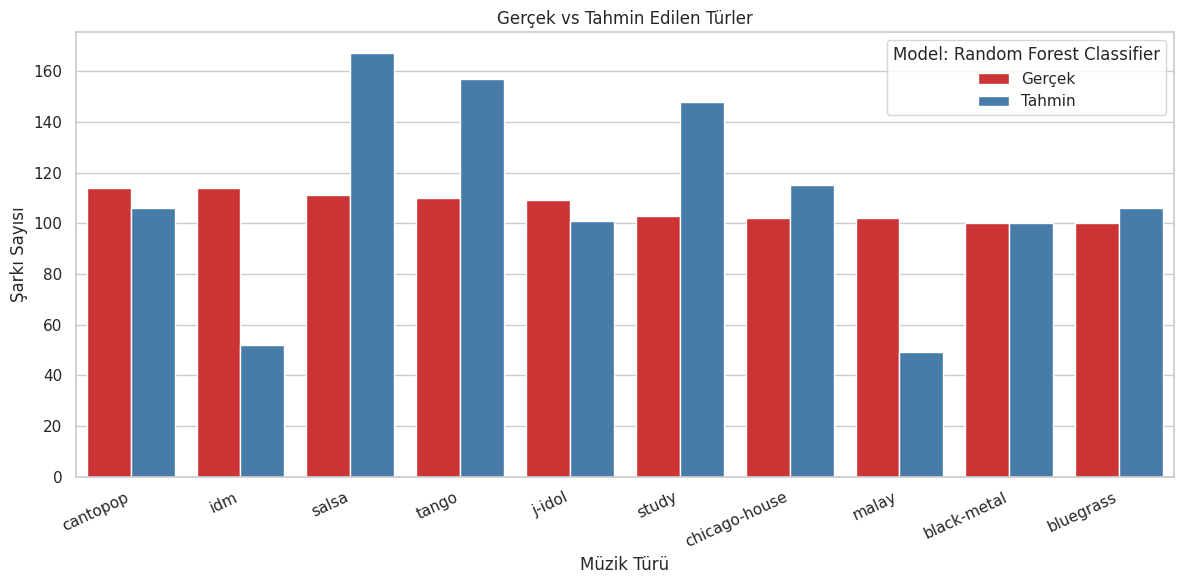

Bu grafik en iyi modelin seçili türlerde gerçek ve tahmin edilen şarkı sayılarını karşılaştırır. Gerçek ve tahmin çubuklarının yakın olması modelin tür dağılımını daha iyi yakaladığını gösterir.


In [11]:
# Görsel 8: En iyi model için gerçek vs tahmin edilen türler
top_actual_genres = predictions_df["actual_genre"].value_counts().head(10).index
actual_counts = predictions_df["actual_genre"].value_counts().reindex(top_actual_genres, fill_value=0)
predicted_counts = predictions_df["predicted_genre"].value_counts().reindex(top_actual_genres, fill_value=0)

comparison_df = pd.DataFrame({
    "Tür": top_actual_genres,
    "Gerçek": actual_counts.values,
    "Tahmin": predicted_counts.values,
}).melt(id_vars="Tür", var_name="Değer Tipi", value_name="Şarkı Sayısı")

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="Tür", y="Şarkı Sayısı", hue="Değer Tipi", palette="Set1")
plt.title("Gerçek vs Tahmin Edilen Türler")
plt.xlabel("Müzik Türü")
plt.ylabel("Şarkı Sayısı")
plt.xticks(rotation=25, ha="right")
plt.legend(title=f"Model: {best_model_name}")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel8_gercek_vs_tahmin.png", dpi=150)
plt.show()
print("Bu grafik en iyi modelin seçili türlerde gerçek ve tahmin edilen şarkı sayılarını karşılaştırır. Gerçek ve tahmin çubuklarının yakın olması modelin tür dağılımını daha iyi yakaladığını gösterir.")


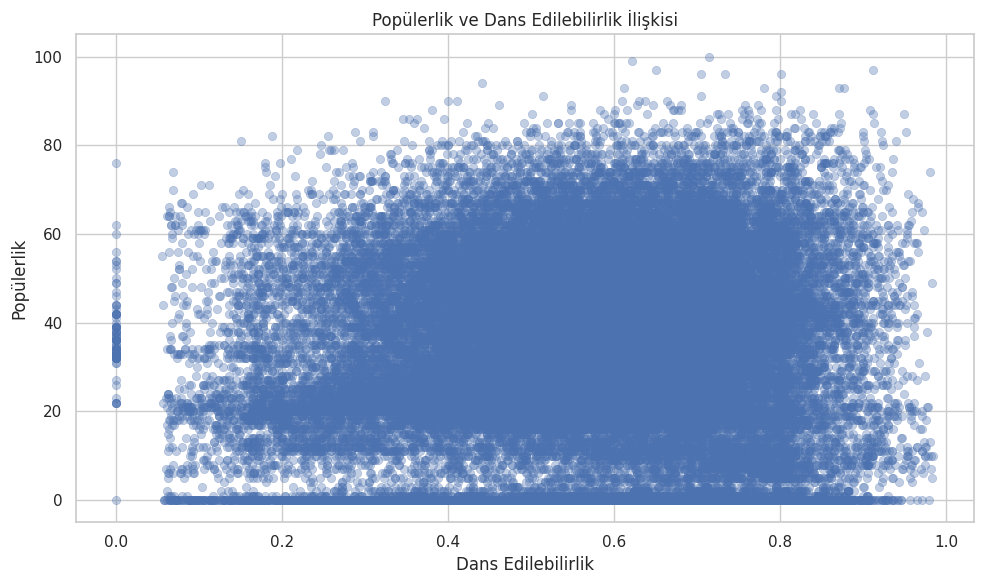

Bu scatter plot popularity ile danceability arasındaki ilişkiyi gösterir. Noktaların genel yönü, dans edilebilirliği yüksek şarkıların popülerlikle nasıl ilişkilendiğini yorumlamaya yardımcı olur.


In [12]:
# Görsel 9: Popularity vs danceability scatter plot
required_columns = ["popularity", "danceability"]
missing_columns = [col for col in required_columns if col not in delta_df.columns]
if missing_columns:
    raise ValueError(f"Delta tablosunda eksik kolonlar var: {missing_columns}")

scatter_pdf = (
    delta_df
    .select(
        F.col("popularity").cast("double").alias("popularity"),
        F.col("danceability").cast("double").alias("danceability"),
    )
    .where(F.col("popularity").isNotNull() & F.col("danceability").isNotNull())
    .limit(50000)
    .toPandas()
)
if scatter_pdf.empty:
    raise ValueError("Popularity ve danceability için çizilecek geçerli kayıt bulunamadı.")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_pdf, x="danceability", y="popularity", alpha=0.35, edgecolor=None)
plt.title("Popülerlik ve Dans Edilebilirlik İlişkisi")
plt.xlabel("Dans Edilebilirlik")
plt.ylabel("Popülerlik")
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel9_scatter.png", dpi=150)
plt.show()
print("Bu scatter plot popularity ile danceability arasındaki ilişkiyi gösterir. Noktaların genel yönü, dans edilebilirliği yüksek şarkıların popülerlikle nasıl ilişkilendiğini yorumlamaya yardımcı olur.")


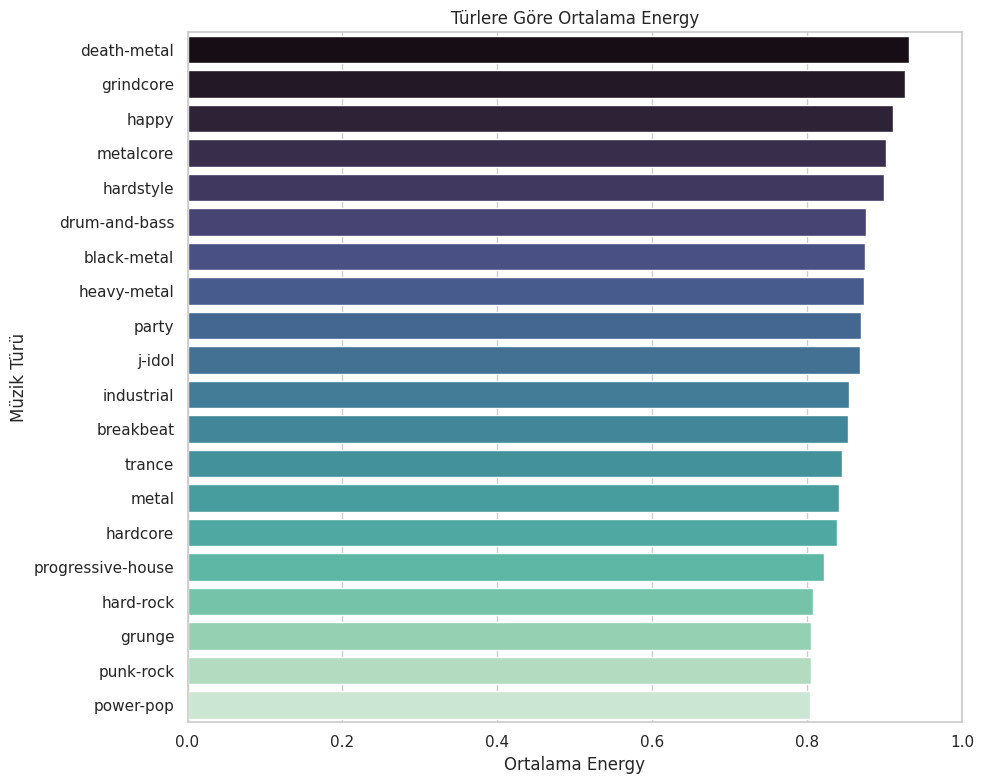

Bu yatay çubuk grafik müzik türlerine göre ortalama energy değerlerini karşılaştırır. Daha uzun çubuklar, ilgili türdeki şarkıların ortalama olarak daha yüksek enerjiye sahip olduğunu gösterir.


In [13]:
# Görsel 10: Tür bazında ortalama energy karşılaştırması
required_columns = ["track_genre", "energy"]
missing_columns = [col for col in required_columns if col not in delta_df.columns]
if missing_columns:
    raise ValueError(f"Delta tablosunda eksik kolonlar var: {missing_columns}")

genre_energy_pdf = (
    delta_df
    .where(F.col("track_genre").isNotNull() & F.col("energy").isNotNull())
    .groupBy("track_genre")
    .agg(F.avg(F.col("energy").cast("double")).alias("Ortalama Energy"))
    .orderBy(F.desc("Ortalama Energy"))
    .limit(20)
    .toPandas()
)
if genre_energy_pdf.empty:
    raise ValueError("Tür ve energy için çizilecek geçerli kayıt bulunamadı.")

plt.figure(figsize=(10, 8))
sns.barplot(data=genre_energy_pdf, y="track_genre", x="Ortalama Energy", palette="mako")
plt.title("Türlere Göre Ortalama Energy")
plt.xlabel("Ortalama Energy")
plt.ylabel("Müzik Türü")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel10_tur_energy.png", dpi=150)
plt.show()
print("Bu yatay çubuk grafik müzik türlerine göre ortalama energy değerlerini karşılaştırır. Daha uzun çubuklar, ilgili türdeki şarkıların ortalama olarak daha yüksek enerjiye sahip olduğunu gösterir.")


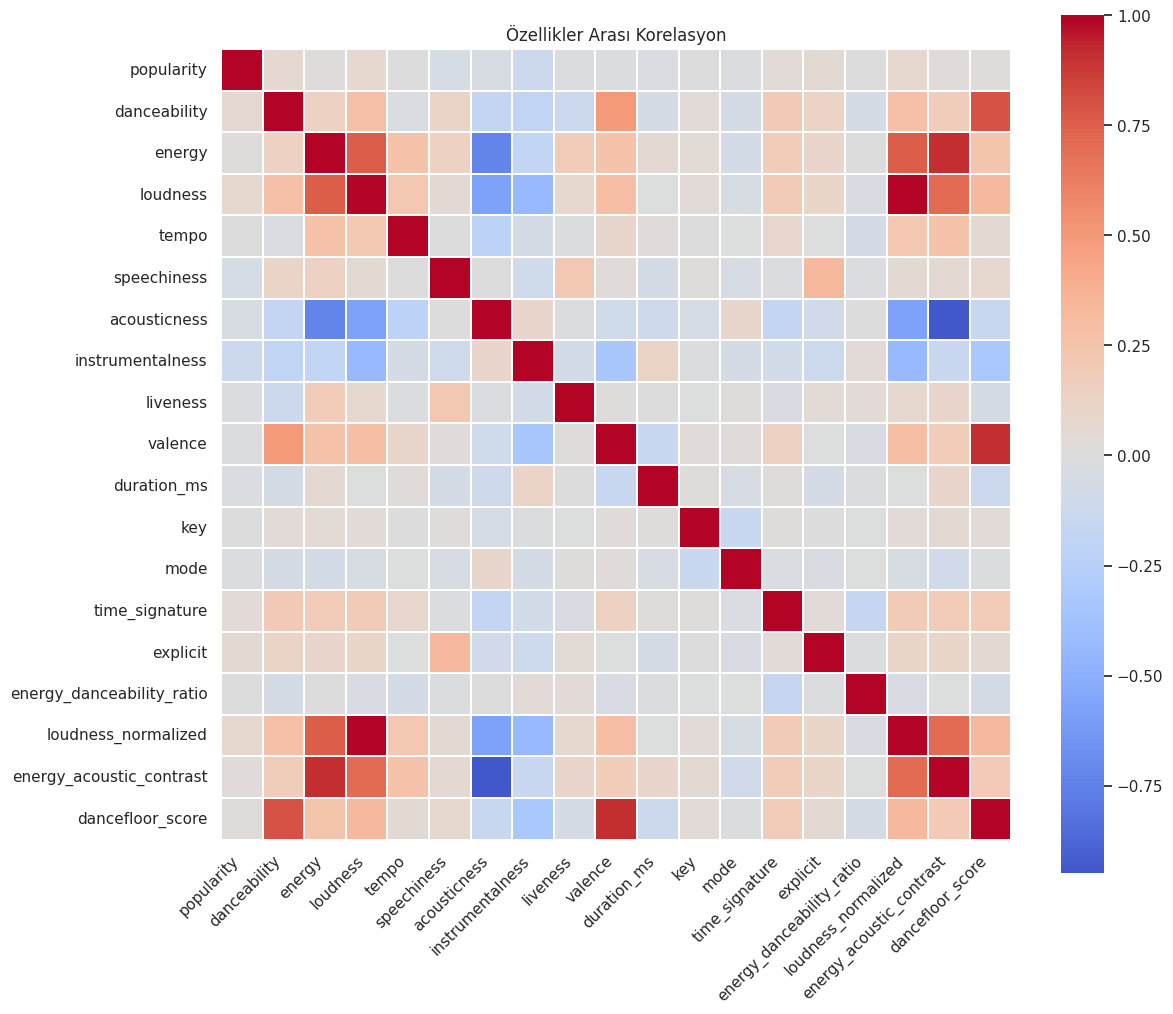

Bu korelasyon heatmap'i sayısal özelliklerin birbirleriyle doğrusal ilişki düzeyini gösterir. Pozitif veya negatif güçlü renkler, özellikler arasında daha belirgin ilişki olduğunu anlatır.


In [14]:
# Görsel 11: Tüm sayısal kolonlar için korelasyon heatmap
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql.types import NumericType

numeric_columns = [
    field.name
    for field in delta_df.schema.fields
    if isinstance(field.dataType, NumericType)
]
if len(numeric_columns) < 2:
    raise ValueError("Korelasyon heatmap için en az iki sayısal kolon gerekir.")

numeric_df = delta_df.select(*[
    F.col(col_name).cast("double").alias(col_name)
    for col_name in numeric_columns
])
assembler = VectorAssembler(
    inputCols=numeric_columns,
    outputCol="numeric_features",
    handleInvalid="skip",
)
assembled_df = assembler.transform(numeric_df).select("numeric_features")
if assembled_df.limit(1).count() == 0:
    raise ValueError("Korelasyon hesaplamak için geçerli sayısal kayıt bulunamadı.")

corr_matrix = Correlation.corr(assembled_df, "numeric_features", "pearson").head()[0].toArray()
corr_pdf = pd.DataFrame(corr_matrix, index=numeric_columns, columns=numeric_columns)

plt.figure(figsize=(max(10, len(numeric_columns) * 0.65), max(8, len(numeric_columns) * 0.55)))
sns.heatmap(corr_pdf, cmap="coolwarm", center=0, annot=False, square=True, linewidths=0.25)
plt.title("Özellikler Arası Korelasyon")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(DASHBOARD_DIR / "gorsel11_korelasyon.png", dpi=150)
plt.show()
print("Bu korelasyon heatmap'i sayısal özelliklerin birbirleriyle doğrusal ilişki düzeyini gösterir. Pozitif veya negatif güçlü renkler, özellikler arasında daha belirgin ilişki olduğunu anlatır.")


## Kaydedilen Görseller

Bu notebook bittiğinde şu PNG dosyaları oluşur:

- `dashboard/gorsel1_model_karsilastirma.png`
- `dashboard/gorsel2_feature_importance.png`
- `dashboard/gorsel3_confusion_matrix.png`
- `dashboard/gorsel4_roc_curve.png`
- `dashboard/gorsel5_zaman_serisi.png`
- `dashboard/gorsel6_popularity_histogram.png`
- `dashboard/gorsel7_tur_dagilimi_pie.png`
- `dashboard/gorsel8_gercek_vs_tahmin.png`
- `dashboard/gorsel9_scatter.png`
- `dashboard/gorsel10_tur_energy.png`
- `dashboard/gorsel11_korelasyon.png`
